Original Image Pixel Values:
[[161 161 162 ... 154 139 128]
 [162 162 162 ... 155 140 129]
 [162 162 162 ... 156 140 128]
 ...
 [ 44  44  44 ... 103 102 101]
 [ 44  44  45 ... 108 107 105]
 [ 43  44  46 ... 109 108 107]]

Gamma Transformed Image Pixel Values:
[[ 94  94  93 ... 101 116 127]
 [ 93  93  93 ... 100 115 126]
 [ 93  93  93 ...  99 115 127]
 ...
 [211 211 211 ... 152 153 154]
 [211 211 210 ... 147 148 150]
 [212 211 209 ... 146 147 148]]


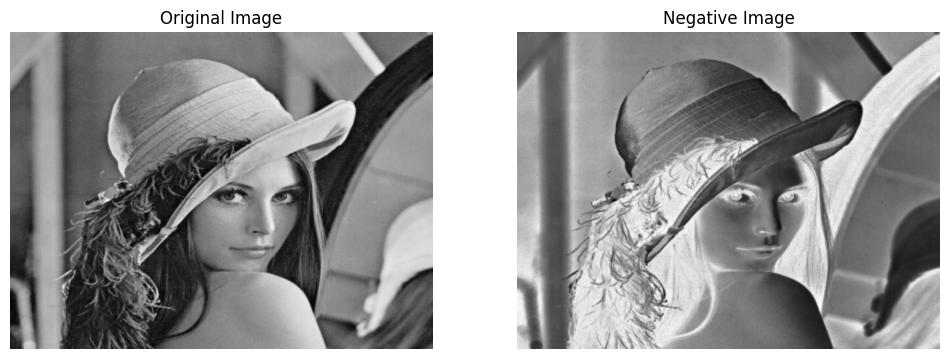

Original Image Pixel Values:
[[161 161 162 ... 154 139 128]
 [162 162 162 ... 155 140 129]
 [162 162 162 ... 156 140 128]
 ...
 [ 44  44  44 ... 103 102 101]
 [ 44  44  45 ... 108 107 105]
 [ 43  44  46 ... 109 108 107]]

Gamma Transformed Image Pixel Values:
[[235 235 236 ... 233 229 225]
 [236 236 236 ... 234 229 225]
 [236 236 236 ... 234 229 225]
 ...
 [176 176 176 ... 215 214 214]
 [176 176 177 ... 217 217 216]
 [175 176 178 ... 217 217 217]]


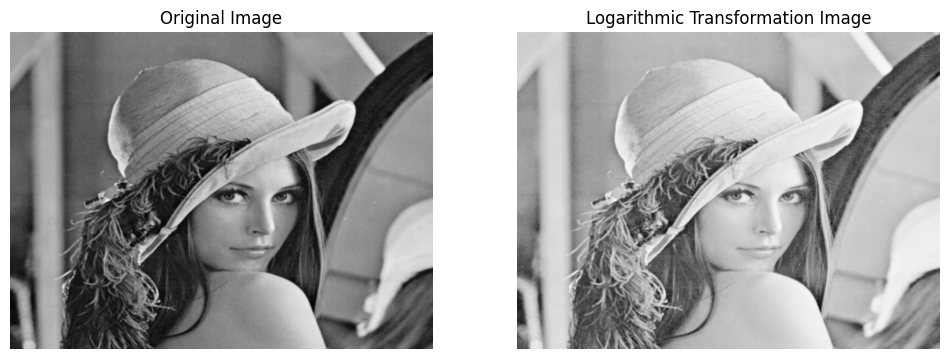

Original Image Pixel Values:
[[161 161 162 ... 154 139 128]
 [162 162 162 ... 155 140 129]
 [162 162 162 ... 156 140 128]
 ...
 [ 44  44  44 ... 103 102 101]
 [ 44  44  45 ... 108 107 105]
 [ 43  44  46 ... 109 108 107]]

Gamma Transformed Image Pixel Values:
[[21 21 21 ... 20 19 18]
 [21 21 21 ... 20 19 18]
 [21 21 21 ... 20 19 18]
 ...
 [ 9  9  9 ... 16 16 15]
 [ 9  9  9 ... 16 16 16]
 [ 9  9  9 ... 16 16 16]]


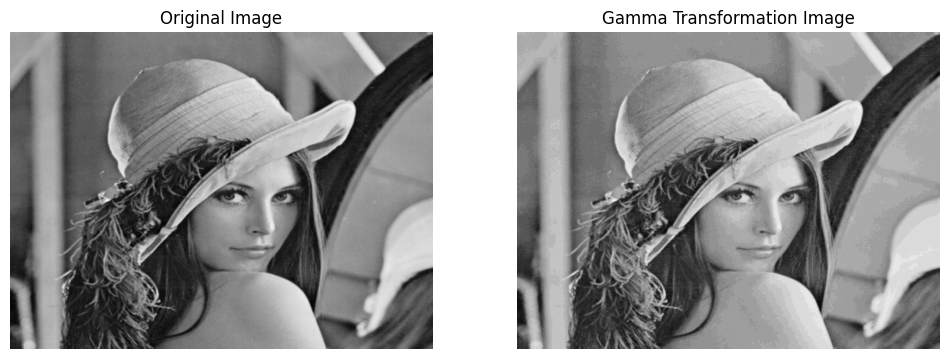

Original Image Pixel Values:
[[161 161 162 ... 154 139 128]
 [162 162 162 ... 155 140 129]
 [162 162 162 ... 156 140 128]
 ...
 [ 44  44  44 ... 103 102 101]
 [ 44  44  45 ... 108 107 105]
 [ 43  44  46 ... 109 108 107]]

Gamma Transformed Image Pixel Values:
[[255 255 255 ... 255   0   0]
 [255 255 255 ... 255   0   0]
 [255 255 255 ... 255   0   0]
 ...
 [  0   0   0 ...   0   0   0]
 [  0   0   0 ...   0   0   0]
 [  0   0   0 ...   0   0   0]]


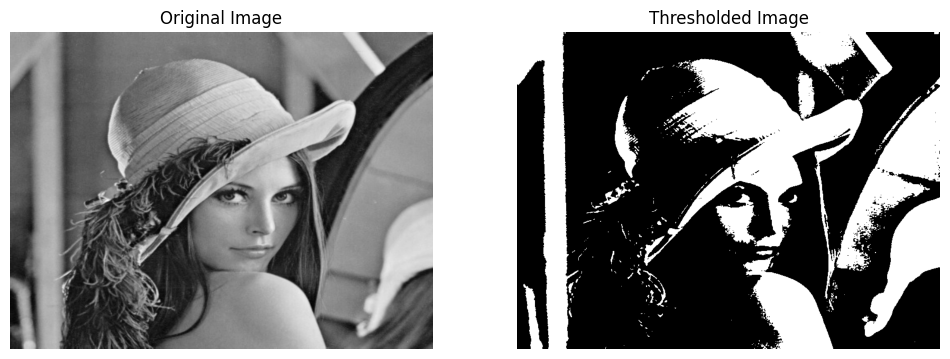

/tmp/ipython-input-3-3813619442.py:158: RuntimeWarning: overflow encountered in scalar multiply
  final_img[i, j] = 255 * (img_resized[i, j] - min_pixel) / (max_pixel - min_pixel)


Original Image Pixel Values:
[[161 161 162 ... 154 139 128]
 [162 162 162 ... 155 140 129]
 [162 162 162 ... 156 140 128]
 ...
 [ 44  44  44 ... 103 102 101]
 [ 44  44  45 ... 108 107 105]
 [ 43  44  46 ... 109 108 107]]

Contrast Stretched Transformed Image Pixel Values:
[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [1 1 1 ... 0 0 0]
 [1 1 1 ... 0 0 0]
 [1 1 1 ... 0 0 0]]


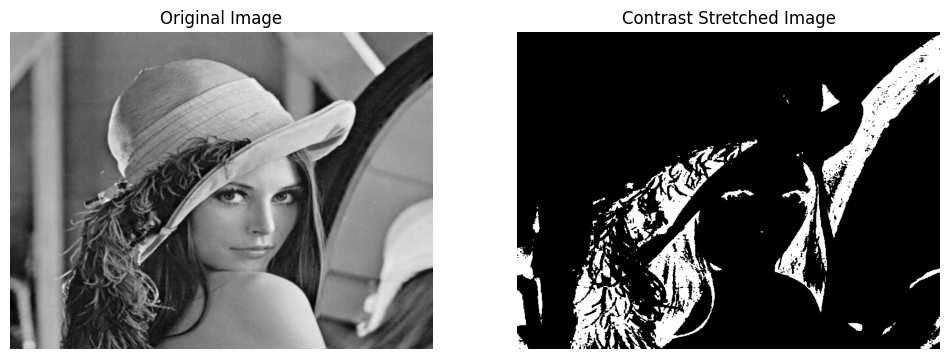

In [ ]:
############# Transformations ##############
import cv2
import numpy as np
import matplotlib.pyplot as plt


img = cv2.imread("lenna.png", cv2.IMREAD_GRAYSCALE)
img_resized = cv2.resize(img, (800, 600))
row, cols = img_resized.shape

###########Negative image transformation:

#The formula is: Output Image, S = L - 1 - r (r = Input Image)

#L = No. of levels (For a 8-bit image, we get, L = 2^8 = 256 levels)

#Grayscale image is a 8-bit image
final_img = np.zeros_like(img_resized)
for i in range(row):
    for j in range(cols):
        final_img[i, j] = 256 - 1 - img_resized[i, j]

# Display the pixel values of the image as a 2D matrix
print("Original Image Pixel Values:")
print(img_resized)

print("\nGamma Transformed Image Pixel Values:")
print(final_img)
plt.figure(figsize=(12, 6))

# Original image
plt.subplot(1, 2, 1)
plt.imshow(img_resized, cmap='gray')
plt.axis('off')
plt.title('Original Image')

# Negative image
plt.subplot(1, 2, 2)
plt.imshow(final_img, cmap='gray')
plt.axis('off')
plt.title('Negative Image')

plt.show()


############Logarithmic Transformation:

#The formula is: Output Image, S = C * log(1+r)

#C = L / log(1 + max. intensity of image)
max_intensity = np.max(img_resized)
C = 255 / np.log(1 + max_intensity)
for i in range(row):
    for j in range(cols):
        final_img[i, j] = C * np.log(1 + img_resized[i, j])

# Display the pixel values of the image as a 2D matrix
print("Original Image Pixel Values:")
print(img_resized)

print("\nGamma Transformed Image Pixel Values:")
print(final_img)
plt.figure(figsize=(12, 6))

# Original image
plt.subplot(1, 2, 1)
plt.imshow(img_resized, cmap='gray')
plt.axis('off')
plt.title('Original Image')

# Negative image
plt.subplot(1, 2, 2)
plt.imshow(final_img, cmap='gray')
plt.axis('off')
plt.title('Logarithmic Transformation Image')

plt.show()



##############Gamma Correlation:

#The formula is: Output image, s = C * r ^ Gamma

#C = Scaling Co-efficient (Normally, C = 1)

gamma = 0.6
for i in range(row):
    for j in range(cols):
        final_img[i, j] = 1 * (img_resized[i, j]) ** gamma

# Display the pixel values of the image as a 2D matrix
print("Original Image Pixel Values:")
print(img_resized)

print("\nGamma Transformed Image Pixel Values:")
print(final_img)
plt.figure(figsize=(12, 6))

# Original image
plt.subplot(1, 2, 1)
plt.imshow(img_resized, cmap='gray')
plt.axis('off')
plt.title('Original Image')

# Negative image
plt.subplot(1, 2, 2)
plt.imshow(final_img, cmap='gray')
plt.axis('off')
plt.title('Gamma Transformation Image')

plt.show()
##############Thresholding Transformation:

#The formula is:

#Output pixel, s = { 0   if r < T { L-1 if r ≥ T r = input pixel value T = threshold value L = number of gray levels (for 8-bit images, L = 256) s = output pixel value

threshold = 150
for i in range(row):
    for j in range(cols):
        if img_resized[i, j] < threshold:
            final_img[i, j] = 0
        else:
            final_img[i, j] = 255

# Display the pixel values of the image as a 2D matrix
print("Original Image Pixel Values:")
print(img_resized)

print("\nGamma Transformed Image Pixel Values:")
print(final_img)
plt.figure(figsize=(12, 6))
# Original image
plt.subplot(1, 2, 1)
plt.imshow(img_resized, cmap='gray')
plt.axis('off')
plt.title('Original Image')
# Thresholded image
plt.subplot(1, 2, 2)
plt.imshow(final_img, cmap='gray')
plt.axis('off')
plt.title('Thresholded Image')
plt.show()

######Contrast Stretching Transformation:

# Formula is: Output Image, S = 255 * (r - r_min)/(r_max - r_min)

# Here, r_min = minimum pixel intensity of image

# r_max = maximum pixel intensity of image

min_pixel = np.min(img_resized)
max_pixel = np.max(img_resized)

for i in range(row):
    for j in range(cols):
        final_img[i, j] = 255 * (img_resized[i, j] - min_pixel) / (max_pixel - min_pixel)

# Display the pixel values of the image as a 2D matrix
print("Original Image Pixel Values:")
print(img_resized)

print("\nContrast Stretched Transformed Image Pixel Values:")
print(final_img)
plt.figure(figsize=(12, 6))
# Original image
plt.subplot(1, 2, 1)
plt.imshow(img_resized, cmap='gray')
plt.axis('off')
plt.title('Original Image')
# Contrast stretched image
plt.subplot(1, 2, 2)
plt.imshow(final_img, cmap='gray')
plt.axis('off')
plt.title('Contrast Stretched Image')
plt.show()